<a href="https://colab.research.google.com/github/srpek137/B1-codes-beginner-/blob/main/RadomDnaGcContent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

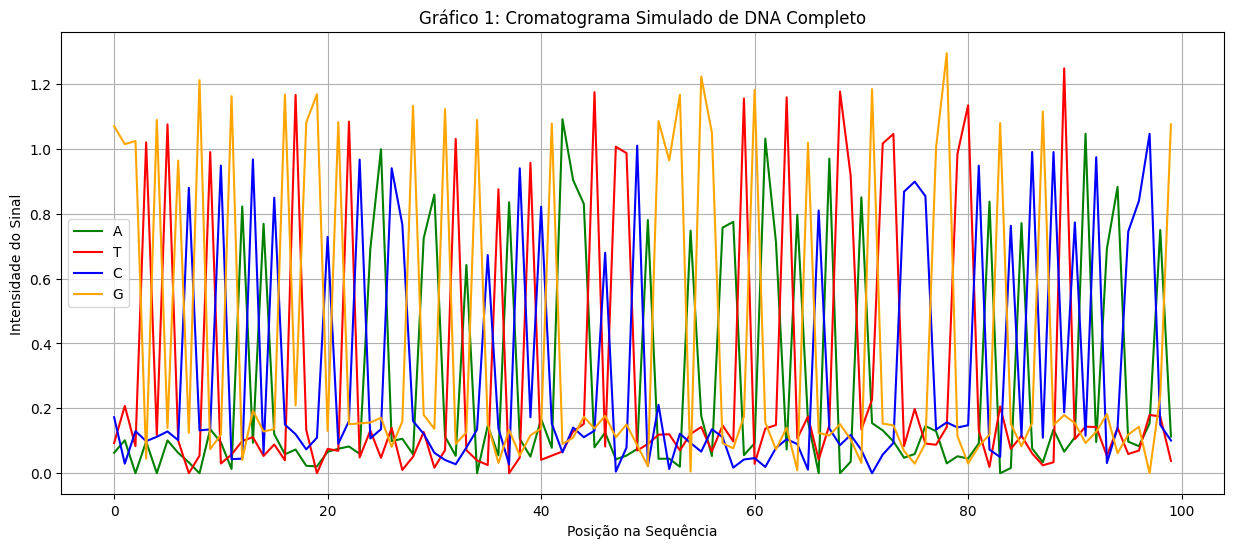

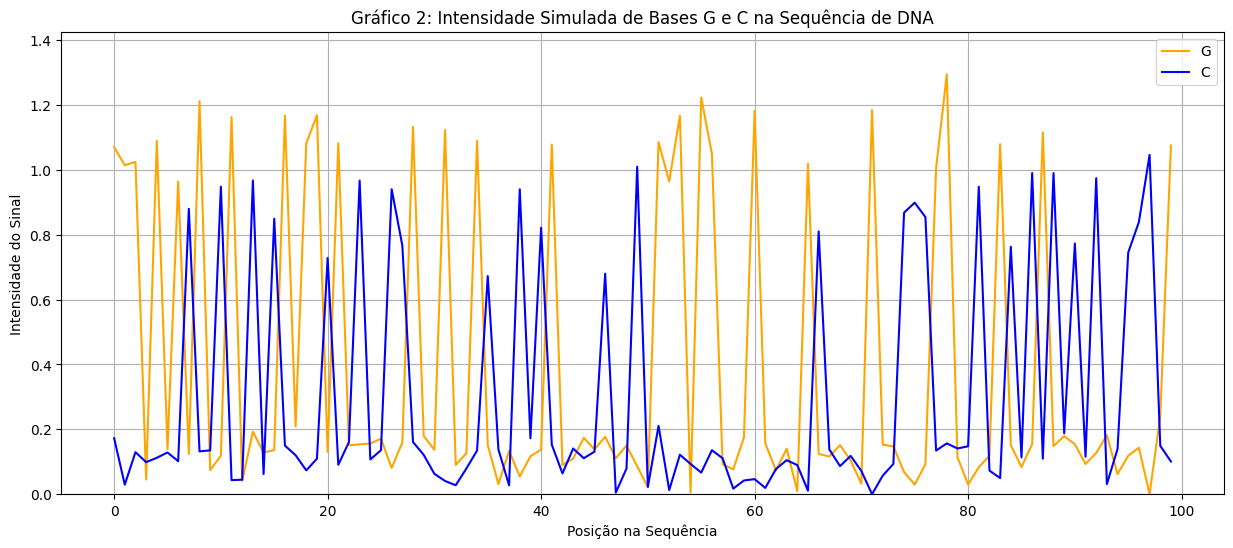

Conteúdo GC da Sequência de DNA: 54.00%


In [44]:
# @title Texto de título padrão
import random
import numpy as np
import matplotlib.pyplot as plt

def gerar_sequencia_dna(comprimento):
    """
    Gera uma sequência de DNA aleatória com o comprimento especificado.

    Args:
        comprimento: O comprimento desejado para a sequência de DNA.

    Returns:
        Uma string representando a sequência de DNA aleatória.
    """
    nucleotideos = ['A', 'T', 'C', 'G']
    sequencia = ''.join([random.choice(nucleotideos) for _ in range(comprimento)])
    return sequencia

def calcular_conteudo_gc(sequencia_dna):
    """
    Calcula o percentual de bases Guanina (G) e Citosina (C) em uma sequência de DNA.

    Args:
        sequencia_dna: Uma string representando a sequência de DNA.

    Returns:
        O percentual de conteúdo GC na sequência.
    """
    gc_count = 0
    for nucleotide in sequencia_dna:
        if nucleotide == 'G' or nucleotide == 'C':
            gc_count += 1
    total_length = len(sequencia_dna)
    gc_content = (gc_count / total_length) * 100 if total_length > 0 else 0
    return gc_content

# Generate the DNA sequence
sequencia_dna = gerar_sequencia_dna(100)
sequence_length = len(sequencia_dna)

# Simulate chromatogram data
intensidade_base = {'A': 0.8, 'T': 1.0, 'C': 0.9, 'G': 1.1}
dados_cromatograma = {'A': [], 'T': [], 'C': [], 'G': []}

for nucleotideo_sequencia in sequencia_dna:
    for base in ['A', 'T', 'C', 'G']:
        if base == nucleotideo_sequencia:
            # Higher intensity for the matching nucleotide with noise
            intensidade = intensidade_base[base] + np.random.normal(0, 0.1)
        else:
            # Lower intensity for non-matching nucleotides with noise
            intensidade = np.random.normal(intensidade_base[base] * 0.1, 0.05)
        dados_cromatograma[base].append(max(0, intensidade)) # Ensure intensity is not negative

# Plot the chromatogram (Gráfico 1)
x_values = np.arange(sequence_length)

plt.figure(figsize=(15, 6))
plt.plot(x_values, dados_cromatograma['A'], color='green', label='A')
plt.plot(x_values, dados_cromatograma['T'], color='red', label='T')
plt.plot(x_values, dados_cromatograma['C'], color='blue', label='C')
plt.plot(x_values, dados_cromatograma['G'], color='orange', label='G')

plt.xlabel("Posição na Sequência")
plt.ylabel("Intensidade do Sinal")
plt.title("Gráfico 1: Cromatograma Simulado de DNA Completo")
plt.legend()
plt.grid(True)
plt.show()

# Calculate GC content (value only)
gc_conteudo = calcular_conteudo_gc(sequencia_dna)

# Plot GC content using chromatogram-like visualization (Gráfico 2)
plt.figure(figsize=(15, 6)) # Set the same figure size as Gráfico 1

# Use the simulated intensity data for G and C from dados_cromatograma
plt.plot(x_values, dados_cromatograma['G'], color='orange', label='G')
plt.plot(x_values, dados_cromatograma['C'], color='blue', label='C')

plt.xlabel("Posição na Sequência")
plt.ylabel("Intensidade do Sinal") # Keep the same y-label as Gráfico 1
plt.title("Gráfico 2: Intensidade Simulada de Bases G e C na Sequência de DNA")
plt.legend()
plt.grid(True)
# Adjust y-axis limits based on the range of G and C intensities
all_gc_intensities = dados_cromatograma['G'] + dados_cromatograma['C']
if all_gc_intensities:
    min_intensity = min(all_gc_intensities)
    max_intensity = max(all_gc_intensities)
    # Add some padding to the y-axis limits
    plt.ylim(min_intensity * 0.9, max_intensity * 1.1)
else:
     plt.ylim(0, 1.5) # Default limits if no G or C
plt.show()

# Display the calculated GC content value
print(f"Conteúdo GC da Sequência de DNA: {gc_conteudo:.2f}%")